In [ ]:
mff_file = "PATH_TO_YOUR_FILE.mff"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.preprocessing import ICA
from autoreject import AutoReject
from mne_icalabel import label_components
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load data
raw = mne.io.read_raw_egi(mff_file, preload=True)

In [4]:
# Set montage
montage = mne.channels.make_standard_montage('GSN-HydroCel-129')
raw.set_montage(montage, on_missing='ignore')

Measurement date,"December 13, 2018 00:10:09 GMT"
Experimenter,Unknown
Participant,Unknown
Digitized points,131 points
Good channels,"129 EEG, 2 Stimulus"
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,1000.00 Hz
Highpass,0.00 Hz
Lowpass,500.00 Hz


In [5]:
# Notch filter (60Hz line noise)
raw.notch_filter(freqs=np.arange(60, 241, 60), picks=['eeg'])

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 129 out of 129 | elapsed:    0.1s finished


Measurement date,"December 13, 2018 00:10:09 GMT"
Experimenter,Unknown
Participant,Unknown
Digitized points,131 points
Good channels,"129 EEG, 2 Stimulus"
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,1000.00 Hz
Highpass,0.00 Hz
Lowpass,500.00 Hz


In [ ]:
# Detect bad channels
data = raw.copy().pick_types(eeg=True).get_data()
ch_std = data.std(axis=1) + np.finfo(float).eps
log_std = -np.log(ch_std)
threshold_flat = np.mean(log_std) + 3 * np.std(log_std)
bad_idx_flat = np.where(log_std > threshold_flat)[0]
threshold_noise = np.mean(ch_std) + 3 * np.std(ch_std)
bad_idx_noise = np.where(ch_std > threshold_noise)[0]
bad_idx = np.unique(np.concatenate([bad_idx_flat, bad_idx_noise]))
eeg_names = raw.copy().pick_types(eeg=True).ch_names
raw.info['bads'] = list(set(raw.info['bads']) | set([eeg_names[i] for i in bad_idx]))

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


In [7]:
# Set reference
raw.set_eeg_reference("average")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


Measurement date,"December 13, 2018 00:10:09 GMT"
Experimenter,Unknown
Participant,Unknown
Digitized points,131 points
Good channels,"121 EEG, 2 Stimulus"
Bad channels,"E17, E51, E57, E68, E104, E107, E125, VREF"
EOG channels,Not available
ECG channels,Not available
Sampling frequency,1000.00 Hz
Highpass,0.00 Hz
Lowpass,500.00 Hz


In [8]:
# ICA for artifact removal
raw_ica = raw.copy().filter(1, 100).pick_types(eeg=True, eog=True)

# Epoch-based artifact rejection
events_ica = mne.make_fixed_length_events(raw_ica, duration=1.0)
epochs_ica = mne.Epochs(raw_ica, events_ica, tmin=0, tmax=1, baseline=None, preload=True)

# AutoReject
ar = AutoReject(random_state=42, thresh_method='bayesian_optimization', n_interpolate=np.array([4, 16, 32]))
epochs_clean_ica, reject_log_ica = ar.fit_transform(epochs_ica, return_log=True)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 3301 samples (3.301 s)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Not setting metadata
69 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 69 events and 1001 original time points ...
0 bad epochs dropped
Running autoreject on ch_type=eeg


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 129 out of 129 | elapsed:    0.1s finished


  0%|          | Creating augmented epochs : 0/121 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/121 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/69 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/69 [00:00<?,       ?it/s]

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.40 and n_interpolate=32


  0%|          | Repairing epochs : 0/69 [00:00<?,       ?it/s]

Dropped 18 epochs: 1, 3, 7, 9, 10, 14, 15, 21, 23, 24, 31, 33, 34, 35, 42, 49, 64, 68


Fitting ICA to data using 121 channels (please be patient, this may take a while)
Selecting by number: 25 components
Computing Extended Infomax ICA
Fitting ICA took 3.2s.


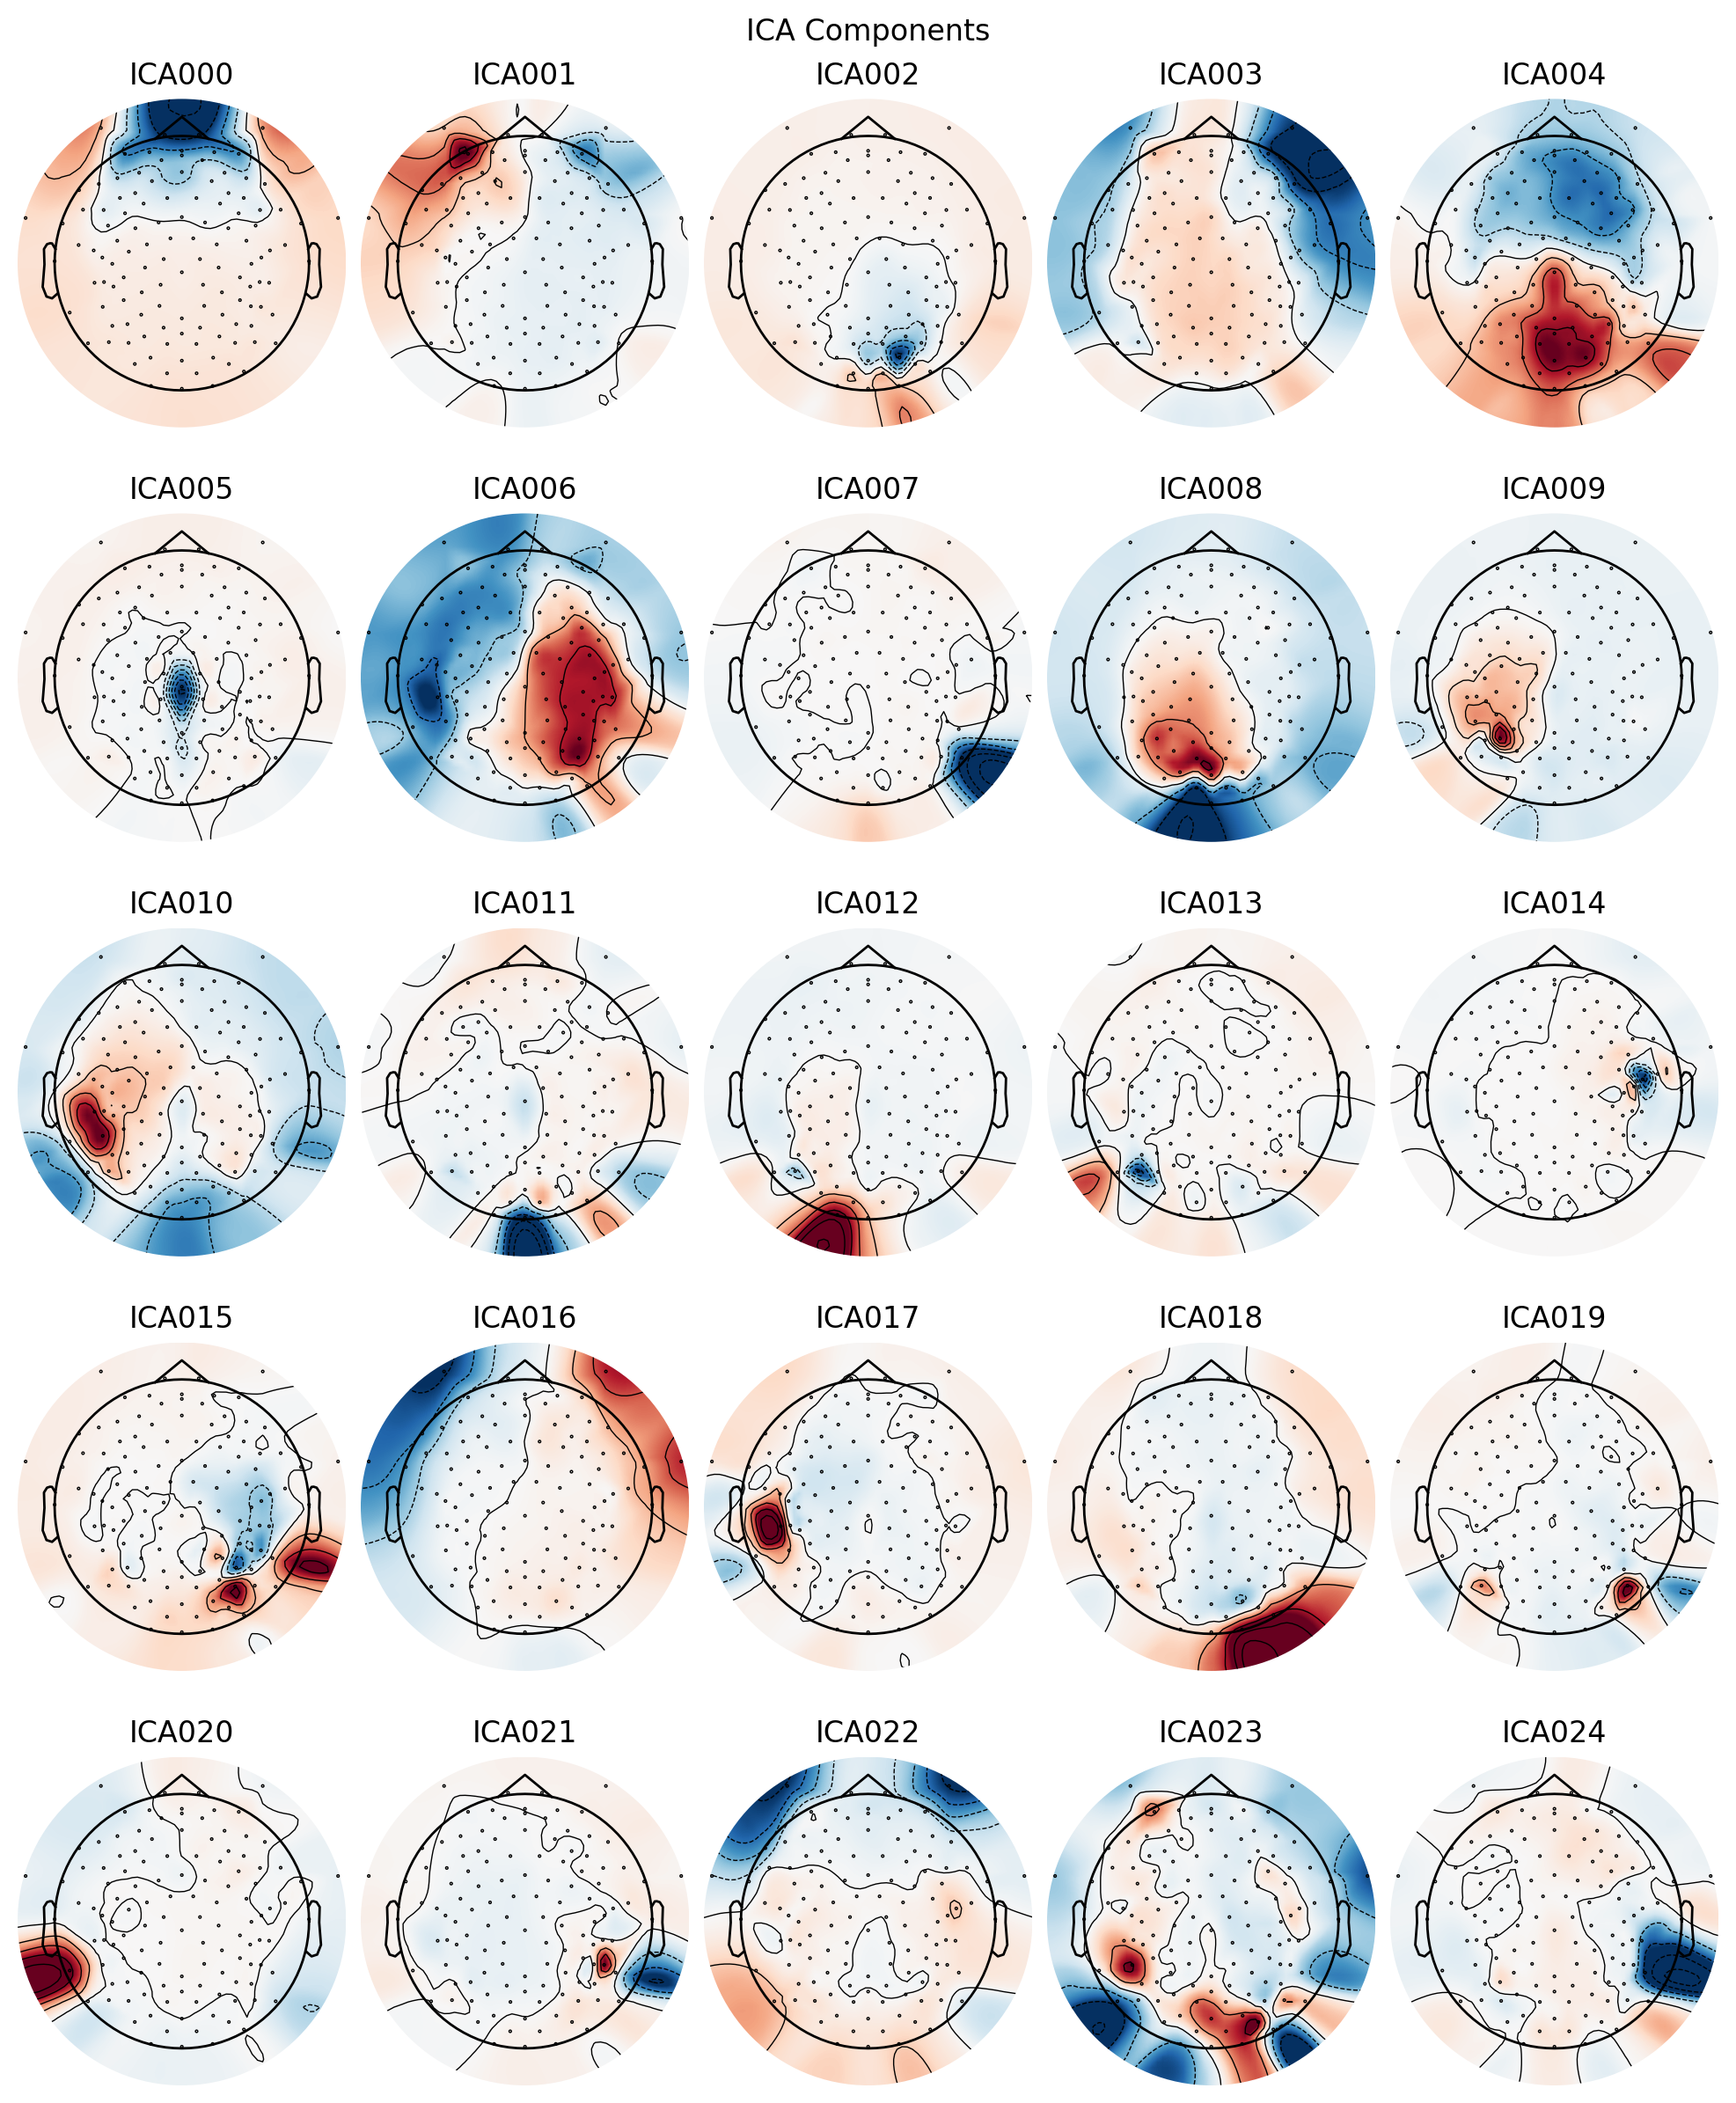

In [9]:
# Get components
ica = ICA(n_components=25, random_state=42, method='infomax', fit_params=dict(extended=True))
ica.fit(epochs_ica[~reject_log_ica.bad_epochs])
ica.plot_components(picks=range(25), title="ICA Components")
plt.show()

In [10]:
ic_labels = label_components(raw_ica, ica, method="iclabel")
exclude = [i for i, label in enumerate(ic_labels["labels"]) 
            if label not in ["brain", "other"]]
ica.apply(raw, exclude=exclude)

Applying ICA to Raw instance
    Transforming to ICA space (25 components)
    Zeroing out 15 ICA components
    Projecting back using 121 PCA components


Measurement date,"December 13, 2018 00:10:09 GMT"
Experimenter,Unknown
Participant,Unknown
Digitized points,131 points
Good channels,"121 EEG, 2 Stimulus"
Bad channels,"E17, E51, E57, E68, E104, E107, E125, VREF"
EOG channels,Not available
ECG channels,Not available
Sampling frequency,1000.00 Hz
Highpass,0.00 Hz
Lowpass,500.00 Hz


In [11]:
# Final bandpass filter
raw.filter(0.1, 80, picks=['eeg'])

# Epoch-based artifact rejection
events = mne.make_fixed_length_events(raw, duration=1.0)
epochs = mne.Epochs(raw, events, tmin=0, tmax=1, baseline=None, preload=True)

# AutoReject 2
ar = AutoReject(random_state=42, thresh_method='bayesian_optimization',
                n_interpolate=np.array([4, 16, 32]))
epochs_clean, reject_log = ar.fit_transform(epochs, return_log=True)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 33001 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.2s


Not setting metadata
69 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 69 events and 1001 original time points ...
0 bad epochs dropped
Running autoreject on ch_type=eeg


[Parallel(n_jobs=1)]: Done 129 out of 129 | elapsed:    0.4s finished


  0%|          | Creating augmented epochs : 0/121 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/69 [00:00<?,       ?it/s]

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.60 and n_interpolate=32


  0%|          | Repairing epochs : 0/69 [00:00<?,       ?it/s]

Dropped 28 epochs: 0, 1, 3, 4, 7, 9, 10, 14, 15, 23, 24, 31, 33, 34, 35, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68


In [ ]:
epochs_clean.plot()

Using qt as 2D backend.
Using pyopengl with version 3.1.9


2025-07-29 10:43:08.613 python[49698:777619129] NSKeyBindingManager: Bad key binding selector for '@~7' = '(
    "setMark:",
    "rightMouseDown:",
    "swapWithMark:"
)'
2025-07-29 10:43:08.613 python[49698:777619129] NSKeyBindingManager: Bad key binding selector for '@~S' = '(
    "saveAs:"
)'
2025-07-29 10:43:08.614 python[49698:777619129] NSKeyBindingManager: Bad key binding selector for '^@w' = '{
    "\t" =     (
        "insertText:",
        "\t"
    );
    "\n" =     (
        "insertNewlineIgnoringFieldEditor:"
    );
    "*" =     (
        "setMark:",
        "moveToBeginningOfParagraph:",
        "insertText:",
        "* ",
        "swapWithMark:",
        "moveRight:",
        "moveRight:"
    );
    "+" =     (
        "setMark:",
        "moveToBeginningOfParagraph:",
        "insertText:",
        "+ ",
        "swapWithMark:",
        "moveRight:",
        "moveRight:"
    );
    "-" =     (
        "setMark:",
        "moveToBeginningOfParagraph:",
        "insertTe

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs...


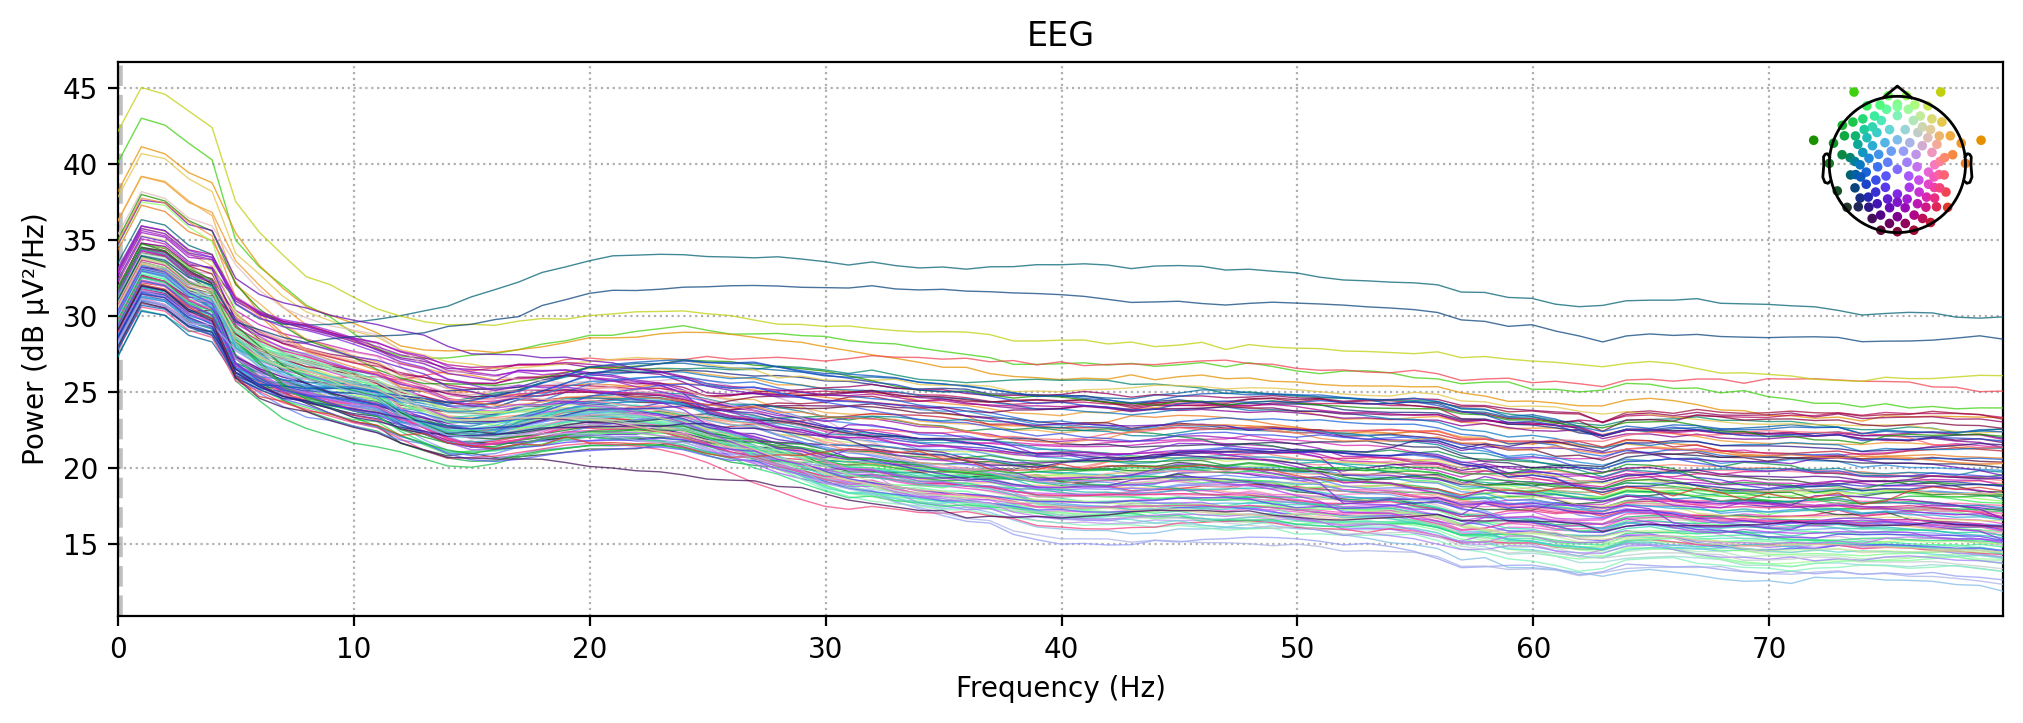

Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
['E17', 'E51', 'E57', 'E68', 'E104', 'E107', 'E125', 'VREF']


In [ ]:
epochs_clean.plot_psd(fmax=80, method='multitaper')